# RL поверх топ-5 альф: лонг / шорт / холд

**Вопрос эксперимента:** может ли простой RL-агент, глядя на состояние рынка и самого
портфеля, решать *когда* держать портфель из топ-5 альф лонгом, когда переворачивать
в шорт, а когда сидеть в кэше — и обыграть тупое «всегда лонг портфеля альф»?

**Правила честности (не нарушать):**
1. Топ-5 отбираем по **fitness = min(TRAIN, VAL)** — TEST в отбор не заглядывает.
   Плюс дедуп по семействам формул (иначе возьмём 5 клонов одной идеи).
2. RL обучается **только на TRAIN + VAL**. TEST — один прогон в самом конце.
3. Никакого выбора лучшего сида: гоняем 12 сидов и смотрим **медиану и разброс**.
   Один удачный сид — это не результат, это лотерея.
4. Каждый переворот позиции платит транзакционный штраф.

Действия агента: **+1** = держать портфель альф, **0** = кэш, **−1** = держать его
зеркально (шорт). Это мета-таймер поверх ансамбля, а не отдельная стратегия.

In [1]:
import os, sys, json, warnings, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore'); np.seterr(all='ignore')
PROJ = os.getcwd()                                   # the notebook lives in the repo root
S = json.load(open(os.path.join(PROJ, 'alphanode', 'gui_settings.json')))
TF = S.get('timeframe', '1d')
os.environ['ALPHANODE_TF'] = TF                      # must be set BEFORE importing config
sys.path[:0] = [os.path.join(PROJ, 'evolution'), PROJ]
from config import load_config
from evaluator import build_panel, make_market, eval_alpha_panel, basket_returns
from fastsim import fast_sim
from genome import parse

cfg = load_config()
ANN, FREQ = float(cfg.get('ann', 365.0)), cfg.get('freq', 'D')
VOL, EXEC = float(S['target_vol']), float(S['exec_cost'])
DATA = os.path.join(PROJ, 'data.pickle' if TF == '1d' else f'data_{TF}.pickle')
LIB = os.path.join(PROJ, 'alphanode', 'state',
                   'library.jsonl' if TF == '1d' else f'library_{TF}.jsonl')
TR, VA, TE, EN = (pd.Timestamp(S[k], tz='UTC') for k in
                  ('train_start', 'val_start', 'test_start', 'test_end'))
N_ALPHAS, SEEDS, SWITCH_COST = 5, 12, 0.0010         # 10 bp per unit of action change
print(f'tf={TF}  ann={ANN:g}  vol={VOL}  exec={EXEC}  data={os.path.basename(DATA)}')
print(f'TRAIN {TR.date()} .. VAL {VA.date()} .. TEST {TE.date()} .. {EN.date()}')

tf=1d  ann=365  vol=0.36  exec=0.0005  data=data.pickle
TRAIN 2019-09-05 .. VAL 2021-11-01 .. TEST 2023-01-01 .. 2026-07-05


## 1. Отбор топ-5 альф — по fitness, с дедупом семейств

In [2]:
rows = [json.loads(l) for l in open(LIB, encoding='utf-8')]
rows = [r for r in rows if r.get('formula') and isinstance(r.get('base'), (int, float))]
rows.sort(key=lambda c: c['base'], reverse=True)
picked = []
for c in rows:                                        # best-first; keep one per formula family
    if all(difflib.SequenceMatcher(None, c['formula'], p['formula']).ratio() < 0.80
           for p in picked):
        picked.append(c)
    if len(picked) == N_ALPHAS:
        break
assert len(picked) == N_ALPHAS, f'library has too few distinct families: {len(picked)}'

def seg(c, s, k):
    v = (c.get(s) or {}).get(k)
    return round(v, 2) if isinstance(v, (int, float)) else None

pd.DataFrame([{'fitness': round(c['base'], 3),
               'train_sh': seg(c, 'train', 'sharpe'), 'val_sh': seg(c, 'val', 'sharpe'),
               'test_sh': seg(c, 'test', 'sharpe'),   # showing it ≠ using it for selection
               'formula': c['formula']} for c in picked])

,fitness,train_sh,val_sh,test_sh,formula
0,2.960,2.96,3.11,1.23,ts_zscore:200(cs_demean(ts_zscore:43(ts_zscore...
1,2.894,2.89,3.12,1.21,cs_zscore(cs_rank(cs_zscore(ts_zscore:83(ts_zs...
2,2.869,2.87,2.91,1.35,cs_zscore(cs_zscore(ema:3(cs_zscore(ts_zscore:...
3,2.860,2.86,3.19,1.14,tanh(cs_zscore(ts_zscore:125(ts_zscore:111(ts_...
4,2.824,2.82,2.91,1.38,slog(ts_roc:60(ts_std:6(sub(pmax(pmax(ts_mean:...


## 2. Дневные NET-доходности каждой альфы и равновзвешенный портфель

Каждая формула прогоняется через тот же движок, что и в поиске (`fast_sim`: vol-таргетинг,
полоса бездействия 10%, комиссия с оборота, funding). Портфель = среднее пяти рядов.

In [3]:
tk, raw, panel = build_panel(DATA, TR.tz_localize(None).to_pydatetime(),
                             EN.tz_localize(None).to_pydatetime(), None, freq=FREQ)
market = make_market(panel, tk, raw, vol_window=cfg.get('vol_window', 30))
R = {}
for c in picked:
    ap = eval_alpha_panel(parse(c['formula']), panel)
    r = fast_sim(ap[tk].to_numpy(dtype=np.float64), market, VOL, EXEC,
                 ann=ANN, ewma_lambda=cfg.get('ewma_lambda', 0.06))
    R[c['formula'][:40]] = r
R = pd.DataFrame(R).fillna(0.0)
p = R.mean(axis=1)                                    # the equal-weight alpha portfolio
bh = basket_returns(panel).reindex(p.index).fillna(0.0)   # buy&hold basket, for reference
idx = p.index
m_train = (idx >= TR) & (idx < VA)
m_val   = (idx >= VA) & (idx < TE)
m_test  = (idx >= TE) & (idx < EN)
m_sel   = m_train | m_val                             # where RL is allowed to learn
corr = R.corr().values[np.triu_indices(N_ALPHAS, 1)]
print(f'{len(p)} bars; mean pairwise corr of the 5 alphas: {corr.mean():+.2f}')

2496 bars; mean pairwise corr of the 5 alphas: +0.48


## 3. Формулировка RL

**Состояние** (всё считается только из прошлого, 36 дискретных состояний):
- моментум портфеля за месяц: вниз / плоско / вверх (мёртвая зона ±0.25σ√21);
- режим волатильности: ниже / выше годовой медианы;
- находится ли портфель в просадке глубже 10%;
- месячный моментум BTC: вниз / плоско / вверх.

**Действия:** −1 (шорт портфеля), 0 (кэш), +1 (лонг).
**Награда:** `a·r(t+1) − 10bp·|a − a_prev|` — прибыль следующего бара минус штраф
за переключение. Табличный Q-learning: маленькое пространство состояний — это
осознанно, у нас всего ~1200 обучающих баров, глубокие сети тут только переобучатся.

In [4]:
mom = p.rolling(21).sum()
sd21 = p.rolling(21).std() * np.sqrt(21)
band = 0.25 * sd21
s_mom = np.select([mom > band, mom < -band], [2, 0], 1)
vol_med = p.rolling(21).std().rolling(252, min_periods=126).median()
s_vol = (p.rolling(21).std() > vol_med).astype(int)
eq_al = (1 + p).cumprod()
s_dd = ((eq_al / eq_al.cummax() - 1) < -0.10).astype(int)
btc_col = next((c for c in panel['ret'].columns if 'BTC' in c), None)
btc = (panel['ret'][btc_col] if btc_col is not None else bh).reindex(idx).fillna(0.0)
bmom, bband = btc.rolling(21).sum(), 0.25 * btc.rolling(21).std() * np.sqrt(21)
s_btc = np.select([bmom > bband, bmom < -bband], [2, 0], 1)

STATE = (((s_mom * 2 + s_vol) * 2 + s_dd.values) * 3 + s_btc).astype(int)
valid = (~(mom.isna() | vol_med.isna() | bmom.isna())).values
STATE[~valid] = -1
NS = 36
r_next = np.append(p.values[1:], 0.0)                 # reward source: NEXT bar's return
print(f'usable bars: {valid.sum()} of {len(p)}; states seen: {len(set(STATE[valid]))} of {NS}')

usable bars: 2351 of 2496; states seen: 36 of 36


## 4. Обучение (только TRAIN+VAL) — 12 сидов

In [5]:
ACT = np.array([-1.0, 0.0, 1.0])

def train_q(seed, epochs=150, lr=0.10, gamma=0.60, eps0=0.30):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, 3))
    steps = np.where(m_sel & valid)[0][:-1]
    for ep in range(epochs):
        eps, a_prev = eps0 * (1 - ep / epochs), 1
        for t in steps:
            s = STATE[t]
            a = int(rng.integers(3)) if rng.random() < eps else int(np.argmax(Q[s]))
            rew = ACT[a] * r_next[t] - SWITCH_COST * abs(ACT[a] - ACT[a_prev])
            s2 = STATE[t + 1]
            nxt = Q[s2].max() if s2 >= 0 else 0.0
            Q[s, a] += lr * (rew + gamma * nxt - Q[s, a])
            a_prev = a
    return Q

def run_policy(Q):
    # greedy actions over the WHOLE span -> per-bar RL returns (costs included)
    a_prev, acts, rl = 1, np.ones(len(p), dtype=int), np.zeros(len(p))
    for t in range(len(p) - 1):
        a = int(np.argmax(Q[STATE[t]])) if STATE[t] >= 0 else 1
        acts[t] = a
        rl[t + 1] = ACT[a] * p.values[t + 1] - SWITCH_COST * abs(ACT[a] - ACT[a_prev])
        a_prev = a
    return acts, pd.Series(rl, index=idx)

runs = []
for seed in range(SEEDS):
    Q = train_q(seed)
    acts, rl = run_policy(Q)
    runs.append({'seed': seed, 'acts': acts, 'rl': rl})
print(f'trained {SEEDS} seeds')

trained 12 seeds


## 5. Результат на замороженном TEST

Сравниваем медианный (по TEST-Sharpe) RL-прогон с бейзлайнами. Если RL не бьёт
«всегда лонг» по медиане — так и записываем: таймер ценности не добавил.

In [6]:
def metrics(r, mask):
    r = r.values[mask] if hasattr(r, 'values') else r[mask]
    act = (r != 0).sum()
    if act < 5 or r.std() < 1e-12:
        return {'sharpe': np.nan, 'cagr': np.nan, 'dd': np.nan}
    eq = np.cumprod(1 + r)
    yrs = len(r) / ANN
    return {'sharpe': r.mean() * ANN / (r.std() * np.sqrt(ANN)),
            'cagr': eq[-1] ** (1 / yrs) - 1 if eq[-1] > 0 else np.nan,
            'dd': (eq / np.maximum.accumulate(eq) - 1).min()}

test_sh = [metrics(x['rl'], m_test)['sharpe'] for x in runs]
order = np.argsort(test_sh)
med = runs[order[len(order) // 2]]                    # the MEDIAN seed, not the best one

table = []
for name, r in [('RL (median seed)', med['rl']), ('always-long portfolio', p),
                ('flat (cash)', p * 0.0), ('buy&hold basket', bh)]:
    row = {'strategy': name}
    for seg_name, mask in [('TRAIN', m_train), ('VAL', m_val), ('TEST', m_test)]:
        m = metrics(r, mask)
        row[f'{seg_name} sharpe'] = round(m['sharpe'], 2)
        row[f'{seg_name} dd'] = f"{m['dd']:.0%}" if np.isfinite(m['dd']) else '—'
    table.append(row)
q1, q3 = np.percentile(test_sh, [25, 75])
print(f'RL TEST sharpe across {SEEDS} seeds: median {np.median(test_sh):+.2f} '
      f'(IQR {q1:+.2f}..{q3:+.2f}, min {min(test_sh):+.2f}, max {max(test_sh):+.2f})')
a_test = med['acts'][m_test]
print(f'median seed on TEST: long {(a_test == 2).mean():.0%} · cash {(a_test == 1).mean():.0%} '
      f'· short {(a_test == 0).mean():.0%} · switches/yr '
      f'{(np.diff(a_test) != 0).sum() / max((m_test.sum() / ANN), 1e-9):.0f}')
pd.DataFrame(table)

RL TEST sharpe across 12 seeds: median -0.17 (IQR -0.23..-0.08, min -0.33, max -0.05)
median seed on TEST: long 10% · cash 44% · short 46% · switches/yr 28


,strategy,TRAIN sharpe,TRAIN dd,VAL sharpe,VAL dd,TEST sharpe,TEST dd
0,RL (median seed),1.73,-3%,2.45,-3%,-0.17,-38%
1,always-long portfolio,3.69,-9%,3.96,-8%,1.65,-32%
2,flat (cash),NaN,—,NaN,—,NaN,—
3,buy&hold basket,2.11,-62%,-1.09,-78%,0.91,-57%


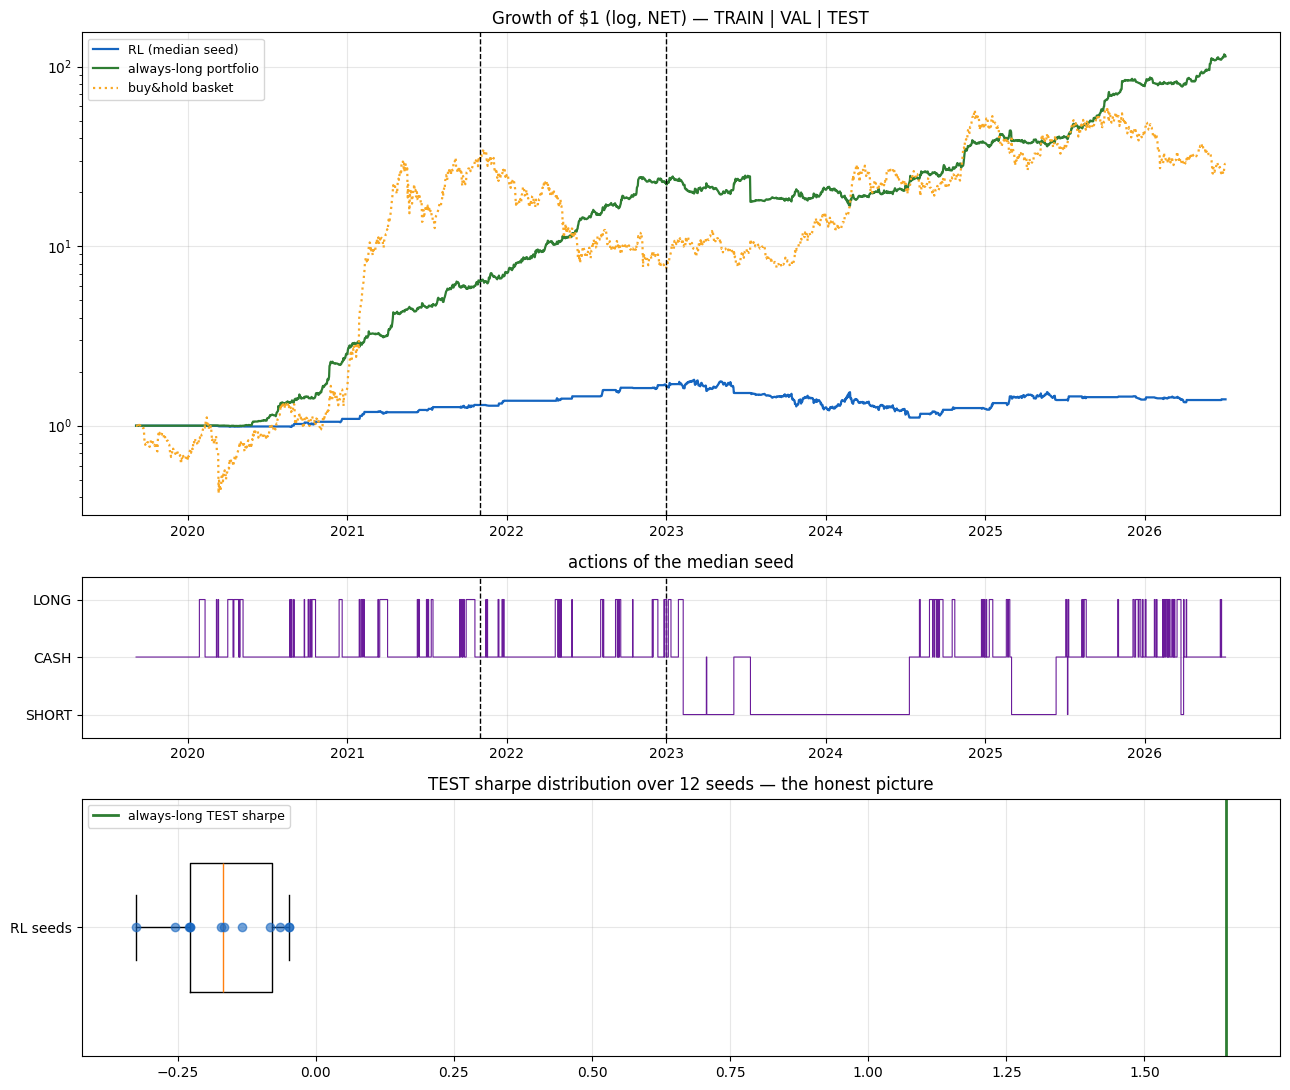

In [7]:
fig, (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 11),
                                   gridspec_kw={'height_ratios': [3, 1, 1.6]})
for r, lbl, col, ls in [(med['rl'], 'RL (median seed)', '#1565c0', '-'),
                        (p, 'always-long portfolio', '#2e7d32', '-'),
                        (bh, 'buy&hold basket', '#f9a825', ':')]:
    ax.plot(idx, (1 + r).cumprod(), lw=1.6, color=col, ls=ls, label=lbl)
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
for x in (VA, TE):
    ax.axvline(x, color='k', ls='--', lw=1)
    ax2.axvline(x, color='k', ls='--', lw=1)
ax.set_title('Growth of $1 (log, NET) — TRAIN | VAL | TEST')

ax2.step(idx, ACT[med['acts']], where='post', lw=0.8, color='#6a1b9a')
ax2.set_yticks([-1, 0, 1]); ax2.set_yticklabels(['SHORT', 'CASH', 'LONG'])
ax2.set_ylim(-1.4, 1.4); ax2.grid(alpha=0.3); ax2.set_title('actions of the median seed')

ax3.boxplot([test_sh], vert=False, widths=0.5, labels=['RL seeds'])
ax3.axvline(metrics(p, m_test)['sharpe'], color='#2e7d32', lw=2, label='always-long TEST sharpe')
ax3.scatter(test_sh, np.ones(len(test_sh)), alpha=0.6, color='#1565c0', zorder=3)
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)
ax3.set_title(f'TEST sharpe distribution over {SEEDS} seeds — the honest picture')
plt.tight_layout(); plt.show()

## 6. Как читать результат

- **Смотри на боксплот, а не на лучший сид.** Если медиана RL ниже зелёной линии
  (always-long) — агент ценности не добавил, и это нормальный результат для 36
  состояний и ~1200 обучающих баров. Отрицательный результат — тоже результат.
- **Если RL выигрывает только за счёт «кэша в просадках»** — то же самое даёт
  правило `if dd < -10%: cash` без всякого RL. Проверь по панели действий: если
  агент почти всегда LONG и уходит в CASH в паре эпизодов — он выучил ровно это.
- **Осторожно с повторами эксперимента.** Каждый новый прогон с другими фичами /
  наградой / γ после взгляда на TEST — это уже подгонка под TEST. Бюджет
  подглядываний здесь — один.

**Куда развивать, если результат интересен:**
1. Walk-forward: переобучать Q каждые полгода на расширяющемся окне — честнее
   одного сплита.
2. Действия-веса по каждой альфе (continuous, −1..+1 на альфу) вместо
   таймера всего портфеля — но это уже требует сотни(!) раз больше данных.
3. Фичи режимов: funding-спред, ширина рынка (breadth), корреляция альф.
4. Сравнить с простыми правилами (vol-targeting самого портфеля, dd-стоп) —
   RL обязан бить и их, иначе он лишняя сложность.